DL Assignment 07

Name - Nikhil Sanjay Patil

Class - CS(AI) B

Batch - 01

Roll no - 06

PRN - 12311506

Problem Statement: Convolutional neural network (CNN) Use any dataset of plant disease and design a plant disease detection system using CNN.

In [ ]:
# Install kaggle
!pip install kaggle

# Upload kaggle.json (your API key)
from google.colab import files
files.upload()

# Setup
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d emmarex/plantdisease

# Unzip
!unzip plantdisease.zip

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
train_dir = "PlantVillage"

img_size = 128
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

In [ ]:
model = Sequential()

# Convolution Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

# Convolution Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Convolution Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(train_data.num_classes, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=7
)

Epoch 1/7
517/517 ━━━━━━━━━━━━━━━━━━━━ 584s 1s/step - accuracy: 0.5672 - loss: 1.3511 - val_accuracy: 0.7751 - val_loss: 0.6967
Epoch 2/7
517/517 ━━━━━━━━━━━━━━━━━━━━ 581s 1s/step - accuracy: 0.7309 - loss: 0.8178 - val_accuracy: 0.8309 - val_loss: 0.5013
Epoch 3/7
517/517 ━━━━━━━━━━━━━━━━━━━━ 587s 1s/step - accuracy: 0.7808 - loss: 0.6581 - val_accuracy: 0.8571 - val_loss: 0.4133
Epoch 4/7
517/517 ━━━━━━━━━━━━━━━━━━━━ 584s 1s/step - accuracy: 0.8217 - loss: 0.5253 - val_accuracy: 0.8831 - val_loss: 0.3655
Epoch 5/7
517/517 ━━━━━━━━━━━━━━━━━━━━ 616s 1s/step - accuracy: 0.8606 - loss: 0.4224 - val_accuracy: 0.9042 - val_loss: 0.2835
Epoch 6/7
517/517 ━━━━━━━━━━━━━━━━━━━━ 581s 1s/step - accuracy: 0.8732 - loss: 0.3666 - val_accuracy: 0.9073 - val_loss: 0.2843
Epoch 7/7
517/517 ━━━━━━━━━━━━━━━━━━━━ 582s 1s/step - accuracy: 0.8977 - loss: 0.3033 - val_accuracy: 0.8894 - val_loss: 0.3236


In [ ]:
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)

129/129 ━━━━━━━━━━━━━━━━━━━━ 40s 307ms/step - accuracy: 0.8894 - loss: 0.3236
Validation Accuracy: 0.8893740773200989


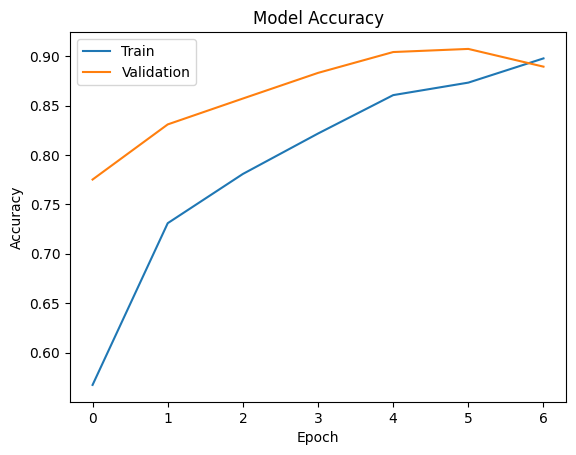

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()